In [130]:
import pandas as pd
import numpy as np

In [131]:
train_df = pd.read_csv('train.csv')
print(train_df.head())

ids = train_df['PassengerId']
y = train_df['Transported'].to_numpy().astype(int)

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  


In [132]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [133]:
for name, col in train_df.items():
    part = col.count() / len(col)
    if part != 1:
        print(name, part)

HomePlanet 0.9768779477740711
CryoSleep 0.9750373864028529
Cabin 0.9771080179454734
Destination 0.9790636144023928
Age 0.9794087196594962
VIP 0.9766478776026688
RoomService 0.9791786494880939
FoodCourt 0.9789485793166915
ShoppingMall 0.9760727021741631
Spa 0.9789485793166915
VRDeck 0.9783734038881859
Name 0.9769929828597722


In [134]:
for name, col in train_df.items():
    print(name)
    print(col.unique())
    print('======================================')

PassengerId
['0001_01' '0002_01' '0003_01' ... '9279_01' '9280_01' '9280_02']
HomePlanet
['Europa' 'Earth' 'Mars' nan]
CryoSleep
[False True nan]
Cabin
['B/0/P' 'F/0/S' 'A/0/S' ... 'G/1499/S' 'G/1500/S' 'E/608/S']
Destination
['TRAPPIST-1e' 'PSO J318.5-22' '55 Cancri e' nan]
Age
[39. 24. 58. 33. 16. 44. 26. 28. 35. 14. 34. 45. 32. 48. 31. 27.  0.  1.
 49. 29. 10.  7. 21. 62. 15. 43. 47.  2. 20. 23. 30. 17. 55.  4. 19. 56.
 nan 25. 38. 36. 22. 18. 42. 37. 13.  8. 40.  3. 54.  9.  6. 64. 67. 61.
 50. 41. 57. 11. 52. 51. 46. 60. 63. 59.  5. 79. 68. 74. 12. 53. 65. 71.
 75. 70. 76. 78. 73. 66. 69. 72. 77.]
VIP
[False True nan]
RoomService
[   0.  109.   43. ... 1569. 8586.  745.]
FoodCourt
[   0.    9. 3576. ... 3208. 6819. 4688.]
ShoppingMall
[   0.   25.  371. ... 1085.  510. 1872.]
Spa
[   0.  549. 6715. ... 2868. 1107. 1643.]
VRDeck
[   0.   44.   49. ... 1164.  971. 3235.]
Name
['Maham Ofracculy' 'Juanna Vines' 'Altark Susent' ... 'Fayey Connon'
 'Celeon Hontichre' 'Propsh Hontichre']

In [135]:
cat_columns = ['PassengerId', 'HomePlanet', 'Cabin', 'Destination', 'Name']
int_columns = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
bool_columns = ['CryoSleep', 'VIP']

In [136]:
from sklearn.base import BaseEstimator, TransformerMixin


class ProcessPassengerId(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.is_fitted_ = True
        return self
    
    def transform(self, X):
        X = X.copy()

        X[['GroupId', 'InGroupId']] = X['PassengerId'].str.split('_', expand=True).astype(int)
        X.drop(columns=['PassengerId'], inplace=True)

        return X
    

class ProcessCabin(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.is_fitted_ = True
        return self
    
    def transform(self, X):
        X = X.copy()

        X[['CabinDeck', 'CabinNum', 'CabinSide']] = X['Cabin'].str.split('/', expand=True)
        notna_mask = X['CabinNum'].notna()
        X.loc[notna_mask, 'CabinNum'] = X.loc[notna_mask, 'CabinNum'].map(int)
        X.drop(columns=['Cabin'], inplace=True)

        return X

In [137]:
cat_columns.remove('PassengerId')
int_columns += ['GroupId', 'InGroupId']

cat_columns.remove('Cabin')
cat_columns += ['CabinDeck', 'CabinSide']
int_columns += ['CabinNum']

In [138]:
from sklearn.pipeline import Pipeline


process_df_columns = Pipeline(steps=[
    ('passengerId', ProcessPassengerId()), 
    ('cabin', ProcessCabin())
])

train_df = process_df_columns.fit_transform(train_df)

In [139]:
train_df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,GroupId,InGroupId,CabinDeck,CabinNum,CabinSide
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,1,1,B,0,P
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,2,1,F,0,S
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,3,1,A,0,S
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,3,2,A,0,S
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,4,1,F,1,S


In [140]:
print(train_df['CabinDeck'].unique())
print(train_df['CabinNum'].unique())
print(train_df['CabinSide'].unique())

['B' 'F' 'A' 'G' nan 'E' 'D' 'C' 'T']
[0 1 2 ... 1892 1893 1894]
['P' 'S' nan]


In [141]:
train_df.shape

(8693, 17)

Transported CryoSleep 0.46280348215356615
CabinDeck HomePlanet -0.4200453951880638
CabinNum GroupId 0.6778440118302629
CabinNum CabinDeck 0.5387766501750586


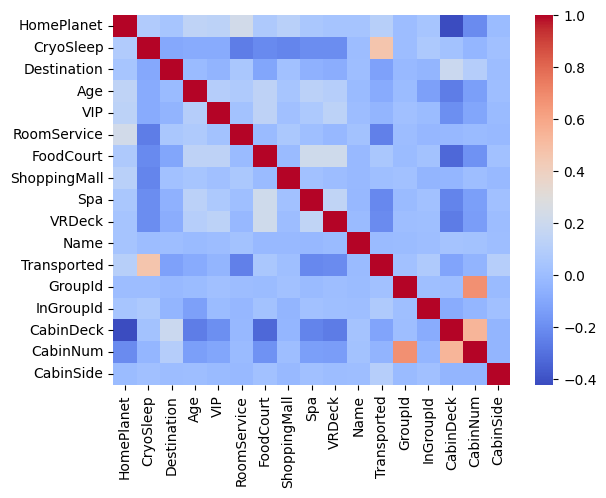

In [142]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder

corr_df = train_df.copy()
corr_df[cat_columns] = OrdinalEncoder().fit_transform(corr_df[cat_columns])
corr_df.dropna(inplace=True)

corr = corr_df.corr()

for i in range(1, corr_df.shape[1]):
    for j in range(i):
        nameA = corr_df.columns[i]
        nameB = corr_df.columns[j]
        if abs(corr[nameA][nameB]) > 0.4:
            print(nameA, nameB, corr[nameA][nameB])
            

sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [143]:
cat_columns.remove('Name')

int_columns.remove('GroupId')
int_columns.remove('InGroupId')

In [144]:
print(cat_columns, int_columns, bool_columns, sep='\n')

['HomePlanet', 'Destination', 'CabinDeck', 'CabinSide']
['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNum']
['CryoSleep', 'VIP']


In [145]:
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, MinMaxScaler

transformer = ColumnTransformer(transformers=[
    ('int', Pipeline(steps=[
        ('imputer', IterativeImputer(random_state=42)),
        ('scaler', MinMaxScaler())
    ]), int_columns),
    ('bool', Pipeline(steps=[
        ('to_float', FunctionTransformer(lambda x: x.astype(float))),
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ]), bool_columns),
    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_columns)
], remainder='drop')

In [146]:
X = transformer.fit_transform(train_df)

In [147]:
print(X.shape)
print(np.isnan(X).any())

(8693, 25)
False


---

In [148]:
from sklearn.model_selection import cross_val_score, GridSearchCV

In [149]:
from sklearn.linear_model import LogisticRegression

print(cross_val_score(LogisticRegression(random_state=42), X, y, scoring='accuracy').mean())

0.762683605182932


In [150]:
from sklearn.tree import DecisionTreeClassifier

print(cross_val_score(DecisionTreeClassifier(random_state=42), X, y, scoring='accuracy').mean())

0.7284085201672059


In [151]:
from sklearn.neighbors import KNeighborsClassifier

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid={'n_neighbors': range(1, 100)},
    scoring='accuracy'
)

grid_search.fit(X, y)

print(grid_search.best_params_)
print(grid_search.best_score_)


print(cross_val_score(KNeighborsClassifier(n_neighbors=10), X, y, scoring='accuracy').mean())

{'n_neighbors': 13}
0.744967975590114
0.7419785453989601


In [152]:
from sklearn.ensemble import RandomForestClassifier

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid = {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2'],
    },
    scoring='accuracy'
)

grid_search.fit(X, y)

print(grid_search.best_params_)
print(grid_search.best_score_)

In [ ]:
from lightgbm import LGBMClassifier

grid_search = GridSearchCV(
    estimator=LGBMClassifier(random_state=42, verbosity=-1),
    param_grid={
        'num_leaves': [5, 10, 20, 31, 40],
        'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
        'n_estimators': [10, 50, 100, 150, 200],
        # 'subsample': [0.8],
        # 'subsample_freq': [1],
        # 'colsample_bytree': [0.8]
    },
    scoring='accuracy'
)

grid_search.fit(X, y)

print(grid_search.best_params_)
print(grid_search.best_score_)

In [ ]:
from lightgbm import LGBMClassifier

grid_search = GridSearchCV(
    estimator=LGBMClassifier(random_state=42, verbosity=-1),
    param_grid={
        'num_leaves': [5, 6, 7, 8, 9, 10],
        'learning_rate': [0.005, 0.01, 0.03, 0.05, 0.07],
        'n_estimators': [10, 50, 100, 150, 200],
        # 'subsample': [0.8],
        # 'subsample_freq': [1],
        # 'colsample_bytree': [0.8]
    },
    scoring='accuracy'
)

grid_search.fit(X, y)

print(grid_search.best_params_)
print(grid_search.best_score_)

In [ ]:
model = LGBMClassifier(random_state=42, verbosity=-1, learning_rate=0.03, n_estimators=150, num_leaves=8)
model.fit(X, y)

---

In [ ]:
test_df = pd.read_csv('test.csv')
ids = test_df['PassengerId']

preprocessor = Pipeline(steps=[
    ('process_df_columns', process_df_columns),
    ('transformer', transformer)
])

X_test = preprocessor.transform(test_df)

In [ ]:
y_test = model.predict(X_test)
y_test = y_test.astype(bool)

In [ ]:
pd.DataFrame({
    'PassengerId': ids,
    'Transported': y_test
}).to_csv('submission.csv', index=False)